<a href="https://colab.research.google.com/github/ALEEEHU/visual_anagrams/blob/main/%E2%80%9C%E2%80%9CIllusionDiffusion_ipynb%E2%80%9D_4_Separate_Sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Illusion Diffusion
By [Matt Tancik](https://www.matthewtancik.com/)

Based on fast.ai [diffusion notebooks](https://github.com/fastai/diffusion-nbs).

![ChessUrl](https://user-images.githubusercontent.com/3310961/218217058-4c3daad4-1e3f-4f14-8c50-782d40c70501.gif "chess")



In [1]:
# @title #Install requirements
!pip install -q --upgrade transformers diffusers ftfy mediapy

from base64 import b64encode

import torch
from diffusers import AutoencoderKL, LMSDiscreteScheduler, UNet2DConditionModel
from huggingface_hub import notebook_login

import numpy as np
import mediapy as mp
import cv2

from pathlib import Path
from torch import autocast
from tqdm.auto import tqdm
from transformers import CLIPTextModel, CLIPTokenizer, logging

torch.manual_seed(1)
if not (Path.home()/'.huggingface'/'token').exists(): notebook_login()

# Supress some unnecessary warnings when loading the CLIPTextModel
logging.set_verbosity_error()

# Set device
torch_device = "cuda" if torch.cuda.is_available() else "cpu"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.1 MB/s eta 0:00:00


In [2]:
# @title #Load Models
# Load the autoencoder model which will be used to decode the latents into image space.
vae = AutoencoderKL.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="vae", torch_dtype=torch.float16)

# Load the tokenizer and text encoder to tokenize and encode the text.
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14")

# The UNet model for generating the latents.
unet = UNet2DConditionModel.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="unet", torch_dtype=torch.float16)

# The noise scheduler
scheduler = LMSDiscreteScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000)

# To the GPU we go!
vae = vae.to(torch_device)
text_encoder = text_encoder.to(torch_device)
unet = unet.to(torch_device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

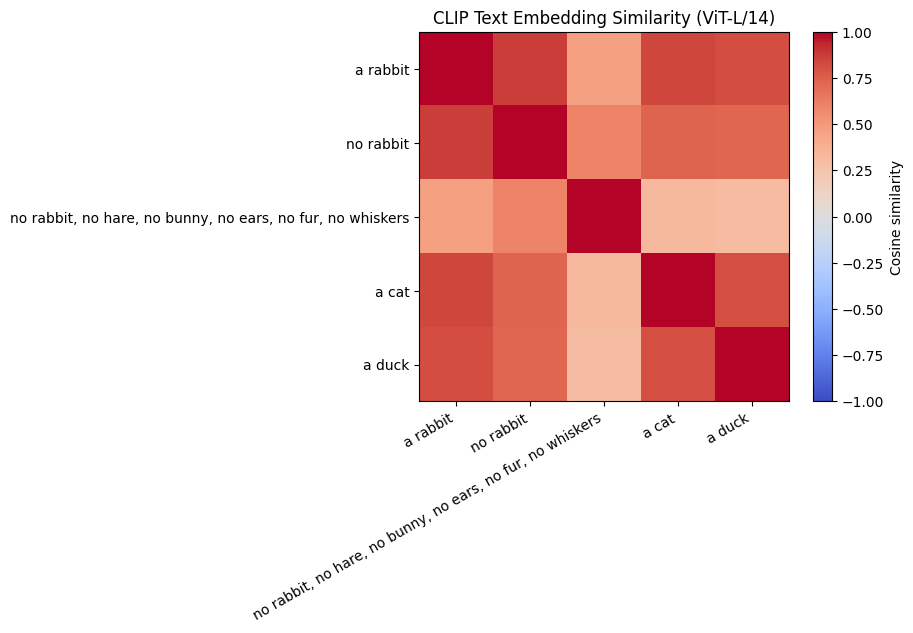

[[1.         0.8733165  0.46405503 0.8398317  0.81895185]
 [0.8733165  1.000001   0.5964458  0.73162955 0.71891016]
 [0.46405503 0.5964458  0.9999999  0.32799184 0.30253753]
 [0.8398317  0.73162955 0.32799184 0.9999998  0.8095364 ]
 [0.81895185 0.71891016 0.30253753 0.8095364  0.9999999 ]]


In [8]:
import torch
from transformers import CLIPTokenizer, CLIPTextModel
import matplotlib.pyplot as plt
import numpy as np

# Device and models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
text_encoder.eval()

# Sentences to compare
texts = ["a rabbit", "no rabbit", "no rabbit, no hare, no bunny, no ears, no fur, no whiskers", "a cat", "a duck"]

# Tokenize and move to device
inputs = tokenizer(texts, padding=True, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# Get text embeddings (masked mean over non-padding tokens)
with torch.no_grad():
    outputs = text_encoder(**inputs)  # [B, T, D]
last_hidden = outputs.last_hidden_state
mask = inputs["attention_mask"].unsqueeze(-1)  # [B, T, 1]
emb_sum = (last_hidden * mask).sum(dim=1)
emb_cnt = mask.sum(dim=1).clamp(min=1)
text_embeds = emb_sum / emb_cnt  # [B, D]
text_embeds = torch.nn.functional.normalize(text_embeds, dim=-1)

# Cosine similarity on CPU
cos_sim = (text_embeds @ text_embeds.T).detach().cpu().numpy()

# Plot
fig, ax = plt.subplots()
im = ax.imshow(cos_sim, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(texts)))
ax.set_yticks(range(len(texts)))
ax.set_xticklabels(texts, rotation=30, ha="right")
ax.set_yticklabels(texts)
plt.colorbar(im, ax=ax, label="Cosine similarity")
plt.title("CLIP Text Embedding Similarity (ViT-L/14)")
plt.show()

print(cos_sim)



show that “a rabbit” vs “no rabbit” is still very close (≈0.87). That confirms “no rabbit” does not act as a logical NOT. It keeps the “rabbit” concept active, only slightly perturbed by “no”. In contrast, “a rabbit” vs the long negative list drops much lower (≈0.46), and that list is also much less similar to “a cat” and “a duck” (≈0.31 and ≈0.29). So stacking exclusions actually pushes the embedding away from “rabbitness” and from small-animal space in general, which is what you want if you are approximating logical negation.

# setting 1: Rabbit/~Rabbit (Adversarial Set)

In [ ]:
import torch
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from contextlib import nullcontext
from torch.cuda.amp import autocast
import time

############################################
# Config
############################################
MODE = "separate_sets"  #@param ["adversarial", "separate_sets"]
# "adversarial" or "separate_sets"
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dtype = torch.float16
use_amp = (dtype == torch.float16) and torch.cuda.is_available()
amp_ctx = autocast() if use_amp else nullcontext()

# positive prompt and negative prompt
pos_prompt = "a rabbit" #@param
neg_prompt = "no rabbit, no hare, no bunny, no ears, no fur, no whiskers" #@param

height = 512
width = 512
num_inference_steps = 80  #@param
guidance_list = [x * 0.5 for x in range(0, 31)]  # 0..15 step=0.5
seed = 42 #@param
batch_size = 1

# Optional rotation to counter orientation bias
use_rotation = False #@param
rotation_deg = 90
rotate_k = (rotation_deg // 90) % 4  # 0,1,2,3

############################################
# Helpers
############################################
def encode_text(prompt: str):
    ids = tokenizer([prompt], padding="max_length",
                    max_length=tokenizer.model_max_length,
                    truncation=True, return_tensors="pt")
    with torch.no_grad():
        emb = text_encoder(ids.input_ids.to(torch_device))[0]
    return emb

def prepare_pair_embeddings(cond_str: str, uncond_str: str):
    cond_emb = encode_text(cond_str)
    uncond_emb = encode_text(uncond_str)
    # For CFG we concatenate [uncond, cond]
    emb = torch.cat([uncond_emb, cond_emb], dim=0)
    return emb

def save_and_show(np_img, path):
    Image.fromarray(np_img).save(path)

############################################
# Core generation (single run)
############################################
def generate_set(cond_str: str, uncond_str: str, tag: str):
    text_input = tokenizer([cond_str], padding="max_length",
                           max_length=tokenizer.model_max_length,
                           truncation=True, return_tensors="pt")
    max_length = text_input.input_ids.shape[-1]

    emb_pair = prepare_pair_embeddings(cond_str, uncond_str)  # [uncond, cond]

    for guidance_scale in guidance_list:
        scheduler.set_timesteps(num_inference_steps, device=torch_device)

        start_t = time.time()
        print(f"\n[{tag}] guidance={guidance_scale}, steps={num_inference_steps}, seed={seed}")

        generator = torch.Generator(device=torch_device.type).manual_seed(seed)
        latents = torch.randn(
            (batch_size, unet.in_channels, height // 8, width // 8),
            generator=generator, device=torch_device, dtype=dtype
        )
        latents = latents * scheduler.init_noise_sigma

        with amp_ctx:
            with torch.inference_mode():
                for i, t in tqdm(enumerate(scheduler.timesteps), total=len(scheduler.timesteps)):
                    if use_rotation and (i % 2 == 0) and rotate_k != 0:
                        latents = torch.rot90(latents, rotate_k, [2, 3])

                    latent_model_input = torch.cat([latents, latents], dim=0)
                    latent_model_input = scheduler.scale_model_input(latent_model_input, t)

                    noise_pred = unet(
                        latent_model_input,
                        t,
                        encoder_hidden_states=emb_pair
                    ).sample

                    noise_uncond, noise_cond = noise_pred.chunk(2, dim=0)
                    noise = noise_uncond + guidance_scale * (noise_cond - noise_uncond)

                    if use_rotation and (i % 2 == 0) and rotate_k != 0:
                        noise = torch.rot90(noise, -rotate_k, [2, 3])
                        latents = torch.rot90(latents, -rotate_k, [2, 3])

                    latents = scheduler.step(noise, t, latents).prev_sample

        # Decode
        latents = latents / 0.18215
        latents = latents.to(dtype=vae.dtype)
        with torch.no_grad():
            image = vae.decode(latents).sample

        image = (image / 2 + 0.5).clamp(0, 1)
        image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
        image = (image * 255).round().astype("uint8")[0, ...]

        mp.show_images([image])
        Image.fromarray(image).save(f"{tag}_guidance_{guidance_scale:.1f}.png")
        print(f"Saved as {tag}_guidance_{guidance_scale:.1f}.png | time {time.time() - start_t:.2f}s")


############################################
# Run modes
############################################
if MODE == "adversarial":
    # cond=positive, uncond=negative (adversarial in a single image)
    generate_set(cond_str=pos_prompt, uncond_str=neg_prompt, tag="adversarial_rabbit")

elif MODE == "separate_sets":
    # Two independent sets (no image has both prompts)
    # Positive set: cond=pos, uncond=""
    generate_set(cond_str=pos_prompt, uncond_str="", tag="pos_only_rabbit")
    # "~Rabbit" set: cond=neg, uncond=""
    generate_set(cond_str=neg_prompt, uncond_str="", tag="neg_only_rabbit")

else:
    raise ValueError("MODE must be 'adversarial' or 'separate_sets'")
